# Analiza Haseł przy użyciu Łańcuchów Markowa
### Autorzy:
- Jan Rapacz
- Żaneta Hofman
- Adrian Adamek

## 1. Wstęp i Konfiguracja
Celem projektu jest stworzenie modelu probabilistycznego, który ocenia siłę hasła na podstawie **prawdopodobieństwa występowania po sobie znaków**.

Model uczy się na bazie zbioru `rockyou.txt` (ok. 14 mln haseł), budując macierz przejść.
* **Biblioteki:** Wykorzystujemy `pandas` do prezentacji danych, `seaborn/matplotlib` do wizualizacji oraz standardowe biblioteki matematyczne.
* **Zbiór danych:** Plik `rockyou.txt` musi znajdować się w katalogu roboczym.

In [37]:
import math
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import defaultdict

DATASET_FILE = "rockyou.txt" 

START_TOKEN = '\x02' 
END_TOKEN = '\x03'


## 2. Implementacja Modelu i Matematyka

Klasa `MarkovPasswordScorer` stanowi główny silnik analityczny projektu. Odpowiada ona za wczytanie danych treningowych, zbudowanie macierzy prawdopodobieństw przejść między znakami, a następnie wykorzystanie tej wiedzy do oceny siły nowych haseł. Klasa ta implementuje logikę matematyczną niezbędną do obsługi rzadkich zdarzeń oraz precyzyjnych obliczeń numerycznych.

### 1. Wzór na prawdopodobieństwo (z wygładzaniem)
Gdy model napotka parę znaków, której nigdy wcześniej nie widział (np. `Z` -> `9`), nie może uznać, że szansa wynosi **0%**, bo to unieważniłoby całe hasło. Stosujemy więc wzór, który zapewnia, że każde przejście jest możliwe:

$$P(next | current) = \frac{count(current \to next) + 1}{count(current) + |V|}$$

**Legenda:**
* **Licznik (`+1`):** Zabezpieczenie przed zerem. Nawet jeśli para wystąpiła 0 razy, traktujemy ją, jakby wystąpiła raz.
* **Mianownik (`+|V|`):** Dodajemy rozmiar alfabetu, aby zachować poprawność matematyczną (suma prawdopodobieństw musi wynosić 100%).

**Przykład obliczeń:**
Załóżmy mini-alfabet **{A, B, C}** (rozmiar $|V|=3$).
W danych treningowych po literze **'A'** wystąpiło 10 razy **'A'**, ale ani razu **'B'**.

* **Pytanie:** Jaka jest szansa na przejście **A -> B**?
* **Bez wzoru:** $0 / 10 = \mathbf{0\%}$ (logarytm z 0 nie istnieje).
* **Z naszym wzorem:**
    $$P(A \to B) = \frac{0 + 1}{10 + 3} = \frac{1}{13} \approx \mathbf{7.6\%}$$

### 2. Zastosowanie logarytmów 
Prawdopodobieństwa w takim modelu są bardzo małe.
* **Problem:** Mnożenie wielu takich liczb (np. dla hasła o długości 20 znaków) prowadzi do błędu numerycznego – komputer może zaookrąglić wyniki do 0.
* **Rozwiązanie:** Zamiast mnożyć prawdopodobieństwa, **dodajemy ich logarytmy**.

**Interpretacja wyniku:**
* **Wynik bliższy 0 (np. -5):** Hasło bardzo typowe, zbudowane z popularnych sekwencji znaków
* **Wynik bardzo niski (np. -50):** Hasło zawiera nietypowe przejścia.

In [ ]:
class MarkovPasswordScorer:

    

    def __init__(self):
        self.transitions = defaultdict(lambda: defaultdict(int))
        self.totals = defaultdict(int)
        self.alphabet = set()
        self.trained = False

    def train(self, filepath):
        if not os.path.exists(filepath):
            print(f"Błąd: Nie znaleziono pliku {filepath}")
            return
        
        print(f"Rozpoczynam trening na: {filepath}")
        
        counter = 0
        
        with open(filepath, 'r', encoding='utf-8', errors='replace') as f:
            for line in f:
                password = line.strip()
                if not password:
                    continue
                
                tokens = [START_TOKEN] + list(password) + [END_TOKEN]
                
                for i in range(len(tokens) - 1):
                    curr, next_char = tokens[i], tokens[i+1]
                    self.transitions[curr][next_char] += 1
                 
                    self.totals[curr] += 1
                    self.alphabet.add(curr)
                    self.alphabet.add(next_char)
                
                counter += 1
                if counter % 1_000_000 == 0:
                    print(f"-> Przetworzono {counter} haseł...")
        
        self.trained = True
        print(f"Trening zakończony! Przetworzono łącznie {counter} haseł.")

    def get_probability(self, char_a, char_b):
        """Oblicza prawdopodobieństwo z wygładzaniem Laplace'a"""
        count = self.transitions[char_a][char_b]
        total = self.totals[char_a]
        vocab_size = len(self.alphabet)
        return (count + 1) / (total + vocab_size) # Laplace smoothing

    def score(self, password):
        """Zwraca wynik jako sumę logarytmów"""
        if not self.trained:
            raise Exception("Model nie jest wytrenowany!")
            
        tokens = [START_TOKEN] + list(password) + [END_TOKEN]
        log_prob_sum = 0.0
        details = []

        for i in range(len(tokens) - 1):
            char_a, char_b = tokens[i], tokens[i+1]
            prob = self.get_probability(char_a, char_b)
            log_prob = math.log10(prob)
            log_prob_sum += log_prob
            details.append((f"{char_a}->{char_b}", prob, log_prob))
            
        return log_prob_sum, details
    

## 3. Proces Uczenia
W tym kroku inicjalizujemy model i przetwarzamy plik `rockyou.txt`. Proces ten tworzy w pamięci mapę powiązań między znakami.

In [39]:
model = MarkovPasswordScorer()

model.train(DATASET_FILE)

Rozpoczynam trening na: rockyou.txt
-> Przetworzono 1000000 haseł...
-> Przetworzono 2000000 haseł...
-> Przetworzono 3000000 haseł...
-> Przetworzono 4000000 haseł...
-> Przetworzono 5000000 haseł...
-> Przetworzono 6000000 haseł...
-> Przetworzono 7000000 haseł...
-> Przetworzono 8000000 haseł...
-> Przetworzono 9000000 haseł...
-> Przetworzono 10000000 haseł...
-> Przetworzono 11000000 haseł...
-> Przetworzono 12000000 haseł...
-> Przetworzono 13000000 haseł...
-> Przetworzono 14000000 haseł...
Trening zakończony! Przetworzono łącznie 14344374 haseł.


## 4. Testowanie i Ranking Haseł

Funkcja `analyze_passwords` przyjmuje listę haseł i ocenia je wytrenowanym modelem.
Dodatkowo obliczamy **Wynik per znak**, co pozwala sprawiedliwie porównywać hasła krótkie z długimi.

* **Interpretacja:** Im wyższy wynik (bliżej zera), tym hasło jest bardziej "ludzkie" i przewidywalne (czyli słabsze).

In [40]:

def analyze_passwords(passwords_list):
    results = []
    for pwd in passwords_list:
        score, _ = model.score(pwd)
        score_per_char = score / (len(pwd) + 2) 
        results.append({
            "Hasło": pwd,
            "Wynik (LogProb)": round(score, 2),
            "Wynik na znak": round(score_per_char, 2)
        })
    
    df = pd.DataFrame(results)
    df = df.sort_values(by="Wynik (LogProb)", ascending=False) 
    return df

test_list = [
    "admin",
    "123456", 
    "password", 
    "admin1", 
    "kochamcie", 
    "TrudneHaslo!", 
    "Xy9#mZ!pL",
    "bardzodlugiehasloalebezcyfr",
    "qwerty",
]

analyze_passwords(test_list)

,Hasło,Wynik (LogProb),Wynik na znak
1,123456,-7.04,-0.88
0,admin,-7.39,-1.06
3,admin1,-8.54,-1.07
8,qwerty,-9.27,-1.16
2,password,-11.57,-1.16
4,kochamcie,-12.08,-1.10
5,TrudneHaslo!,-22.92,-1.64
6,Xy9#mZ!pL,-28.92,-2.63
7,bardzodlugiehasloalebezcyfr,-39.75,-1.37


## 5. Wizualizacja Macierzy przejść dla wybranych znaków

Poniższa mapa pokazuje prawdopodobieństwo przejścia między literami alfabetu (a-z).
* **Oś Y:** Znak obecny.
* **Oś X:** Znak następny.
* **Jasne pola:** Oznaczają bardzo częste pary (np. `q` -> `u`, `t` -> `h` w języku angielskim).
To wizualny dowód na to, że model "nauczył się" struktury języka używanego w hasłach.

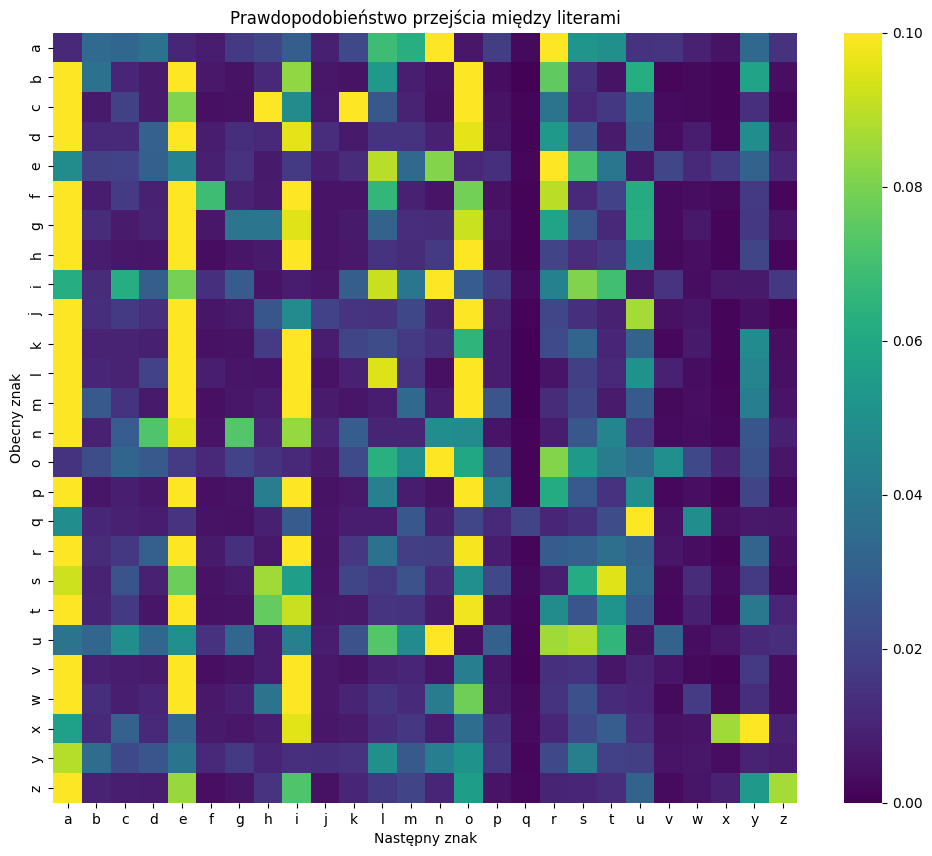

In [41]:
def plot_heatmap(chars_to_show):
    matrix = []
    labels = list(chars_to_show)
    
    for row_char in labels:
        row_data = []
        for col_char in labels:
            prob = model.get_probability(row_char, col_char)
            row_data.append(prob)
        matrix.append(row_data)
        
    df_map = pd.DataFrame(matrix, index=labels, columns=labels)
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(df_map, annot=False, cmap="viridis", vmin=0, vmax=0.1)
    plt.title("Prawdopodobieństwo przejścia między literami")
    plt.xlabel("Następny znak")
    plt.ylabel("Obecny znak")
    plt.show()

# Mapa dla małych liter
plot_heatmap("abcdefghijklmnopqrstuvwxyz")

## 6. Tabela przejść dla wybranego hasła

In [42]:

target_password = "admin"  

score, details = model.score(target_password)

print(f"Analiza dla: '{target_password}' (Total Score: {score:.4f})")
print("-" * 50)
print(f"{'Przejście':<10} | {'Prawdopodobieństwo':<20} | {'Log10'}")
print("-" * 50)

for step in details:
    trans, prob, log = step
    bar = "#" * int(prob * 50) 
    print(f"{trans:<10} | {prob:.6f} {bar:<15} | {log:.4f}")

Analiza dla: 'admin' (Total Score: -7.3893)
--------------------------------------------------
Przejście  | Prawdopodobieństwo   | Log10
--------------------------------------------------
->a       | 0.048913 ##              | -1.3106
a->d       | 0.037591 #               | -1.4249
d->m       | 0.014575                 | -1.8364
m->i       | 0.123637 ######          | -0.9079
i->n       | 0.143786 #######         | -0.8423
n->       | 0.085651 ####            | -1.0673


## 6. Analiza "trajektorii" hasła

* **Oś Y (Log Probability):** Pokazuje jak bardzo model był "zaskoczony" kolejnym znakiem.
* **Wnioski:**
    * Linia płaska i wysoka = Hasło przewidywalne (np. `password123`).
    * Gwałtowne spadki w dół = Momenty wprowadzenia znaku nietypowego/losowego (np. znak specjalny w środku słowa).

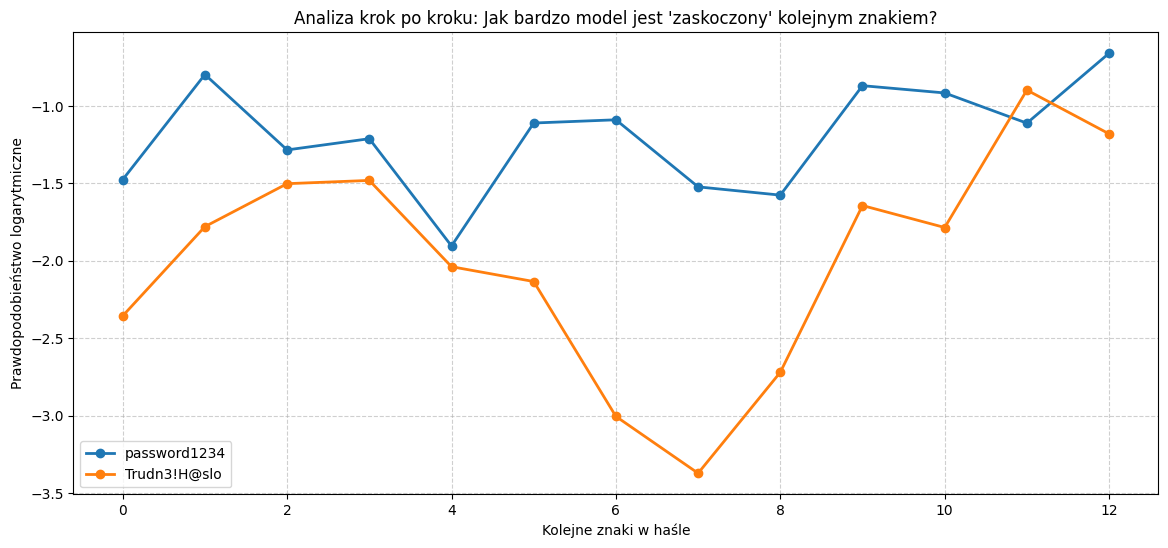

In [43]:

def plot_password_trajectory(passwords):
    plt.figure(figsize=(14, 6))
    
    for pwd in passwords:
        _, details = model.score(pwd)
        
        y_values = [step[2] for step in details]
        x_indices = range(len(y_values))
        
        plt.plot(x_indices, y_values, marker='o', label=f"{pwd}", linewidth=2)
        

    plt.title("Analiza krok po kroku: Jak bardzo model jest 'zaskoczony' kolejnym znakiem?")
    plt.ylabel("Prawdopodobieństwo logarytmiczne")
    plt.xlabel("Kolejne znaki w haśle")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

# PORÓWNANIE: hasło typowe vs losowe
plot_password_trajectory(["password1234", "Trudn3!H@slo"])

## 7. Weryfikacja Modelu: Hasła "ludzkie" vs hasła wygenerowane maszynowo

Aby sprawdzić skuteczność modelu, porównujemy dwie grupy haseł:
1.  **RockYou (Czerwony):** Próbka rzeczywistych haseł stworzonych przez ludzi.
2.  **Losowe (Zielony):** Hasła wygenerowane maszynowo.

Używamy wykresu **Gęstości**, aby znormalizować różnicę w liczebności próbek. Wykres pokazuje wyraźną separację – model poprawnie ocenia hasła losowe jako znacznie mniej prawdopodobne (przesunięcie w lewo) niż hasła ludzkie.

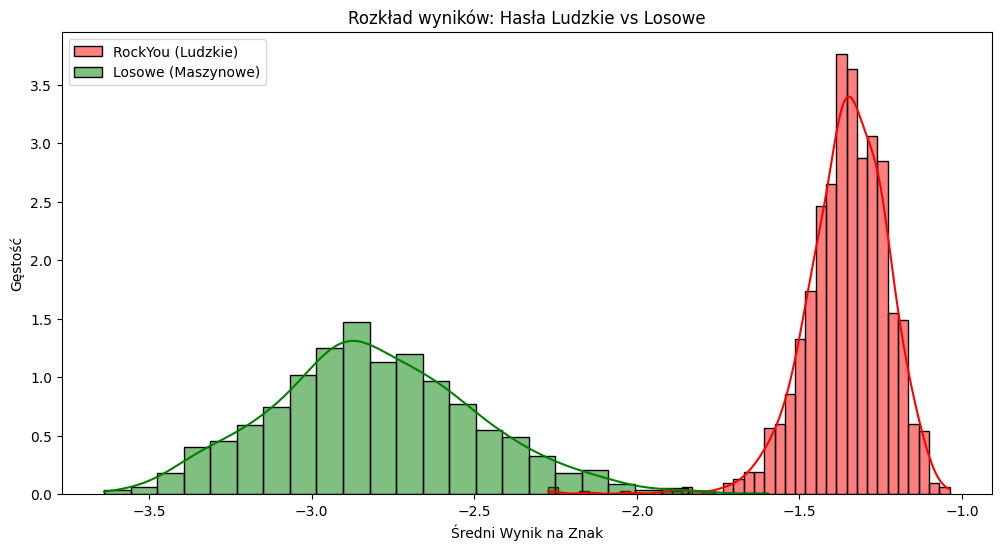

In [44]:
import random
import string

def generate_strong_password(length=10):
    """Generuje losowe hasło"""
    chars = string.ascii_letters + string.digits + "!@#$%^&*"
    return ''.join(random.choice(chars) for _ in range(length))

weak_passwords = []
with open(DATASET_FILE, 'r', encoding='latin-1', errors='ignore') as f:
    for _ in range(1000): # Pierwsze 1000 haseł
        line = f.readline().strip()
        if line: 
            weak_passwords.append(line)

strong_passwords = [generate_strong_password(len(p)) for p in weak_passwords] # Generujemy losowe hasła o tej samej długości jak ludzkie

weak_scores = [model.score(p)[0] / len(p) for p in weak_passwords if len(p) > 0]
strong_scores = [model.score(p)[0] / len(p) for p in strong_passwords if len(p) > 0]

plt.figure(figsize=(12, 6))
sns.histplot(weak_scores, color="red", label="RockYou (Ludzkie)", kde=True, stat="density", alpha=0.5)
sns.histplot(strong_scores, color="green", label="Losowe (Maszynowe)", kde=True, stat="density", alpha=0.5)

plt.title("Rozkład wyników: Hasła Ludzkie vs Losowe")
plt.xlabel("Średni Wynik na Znak")
plt.ylabel("Gęstość")
plt.legend()
plt.show()

## 8. Ranking najpopularniejszych par

Poniższa tabela przedstawia pary znaków, które mają najwyższe prawdopodobieństwo wystąpienia po sobie (dla znaków, które wystąpiły w próbce minimum 100 razy).
Są to "najsłabsze ogniwa" w hasłach użytkowników.

In [45]:
def show_top_transitions(n=10):
    all_transitions = []
    
    for char_a in model.alphabet:
        for char_b in model.alphabet:
            if model.totals[char_a] > 100 and model.totals[char_b] > 100:
                prob = model.get_probability(char_a, char_b)
                all_transitions.append( (char_a, char_b, prob) )
    
    all_transitions.sort(key=lambda x: x[2], reverse=True)
    
    print(f"{'Znak A':<6} -> {'Znak B':<6} | {'Prawdopodobieństwo':<15}")
    print("-" * 40)
    for i in range(min(n, len(all_transitions))):
        a, b, p = all_transitions[i]
        print(f"'{a}'    -> '{b}'    | {p:.2%}")

show_top_transitions(15)

Znak A -> Znak B | Prawdopodobieństwo
----------------------------------------
'\'    -> '\'    | 67.14%
'<'    -> '3'    | 56.42%
'#'    -> '1'    | 44.16%
'q'    -> 'u'    | 44.01%
'v'    -> 'e'    | 37.97%
'Q'    -> 'U'    | 34.51%
'V'    -> 'E'    | 32.06%
'ñ'    -> 'o'    | 29.13%
'ñ'    -> 'a'    | 27.02%
'"'    -> ' '    | 26.68%
'>'    -> '<'    | 26.54%
'm'    -> 'a'    | 24.07%
'j'    -> 'a'    | 22.44%
'h'    -> 'a'    | 21.93%
'\'    -> '''    | 21.35%
